# A calibrated decision classifier on Muse Glimmer 30B

Give the model a piece of **state** (a customer message, a review, a tool call), a **question**, and up to five
lettered **options**; it answers with one letter. Because the answer is a single token, one request returns a
probability for every option, so you get the decision and a confidence score in one fast call. Use it for
ticket routing, policy checks, moderation, sentiment, or "which tool should the agent call".

This notebook trains that classifier on `muse-glimmer-30b` with **serverless LoRA SFT** and evaluates it on
tasks it was trained on and on six tasks it never saw.

| Step | What happens | Billing |
|---|---|---|
| 1. Data | ~51k rows from 35 public classification tasks plus 4 synthetic rule tasks | free |
| 2. Check | render through Muse's renderer; confirm only the answer letter is trained | free |
| 3. Train | 1 epoch, batch 64, LoRA rank 64 on the serverless pool (~25 min) | per token |
| 4. Evaluate | base model, then tuned model, each on a 1x B300 deployment scoring 6,900 rows, deleted after (~2 h total) | per GPU-hour |

Three tricks matter:

**Ask twice (prompt repetition).** The question JSON is sent twice, joined by "Let me repeat that:". In a
left-to-right model the first copy's tokens can't see what comes after them; in the second copy every token can
attend to the whole question and its options ([Leviathan et al., 2025](https://arxiv.org/pdf/2512.14982)). The
answer is still one letter, so this costs extra input tokens and no extra output tokens.

```text
{task JSON}

Let me repeat that:

{task JSON}
```

**Teach it to decline.** On 15% of training rows the correct option is removed and the right answer becomes
"None of the listed options matches", so the model learns to say so instead of guessing.

**Check the confidence (temperature scaling).** Fine-tuned models are often overconfident. One temperature `T`,
fit on dev rows, divides every option's log-probability before the softmax: it softens or sharpens all answers by
the same amount and never changes which option wins. Here SFT alone does most of the work (the untrained base is
badly overconfident), so the fitted `T` ends up close to 1; section 5 shows how much it adds.


## Setup

In [ ]:
import json
import math
import os
import sys
import uuid
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from fireworks import Fireworks

import classifier_harness as H

load_dotenv()
ACCOUNT_ID = os.environ["FIREWORKS_ACCOUNT_ID"].replace("accounts/", "")
fw = Fireworks()

# Cookbook root with the training recipes and Muse's renderer; set COOKBOOK_ROOT to use another checkout.
ROOT = Path(os.environ.get("COOKBOOK_ROOT", Path.cwd().parents[2]))
assert (ROOT / "training/renderer/muse_glimmer.py").exists(), f"{ROOT} has no muse_glimmer renderer; update it or set COOKBOOK_ROOT"
sys.path.insert(0, str(ROOT))

BASE_MODEL = "accounts/fireworks/models/muse-glimmer-30b"
TOKENIZER = "meta-models/Muse-Glimmer-30B"
LORA_RANK, LORA_ALPHA, LEARNING_RATE, EPOCHS, BATCH_SIZE, MAX_SEQ_LEN = 64, 32, 1e-4, 1, 64, 8192

RUN_ID = uuid.uuid4().hex[:6]
WORK = Path("runs") / RUN_ID
WORK.mkdir(parents=True, exist_ok=True)
OUTPUT_MODEL_ID = f"muse-classifier-{RUN_ID}"
TUNED_MODEL = f"accounts/{ACCOUNT_ID}/models/{OUTPUT_MODEL_ID}"
print("run", RUN_ID, "->", TUNED_MODEL)

/Users/sinan/cookbook/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run 9da40e -> accounts/pyroworks/models/muse-classifier-9da40e


## 1. Build the data

`classifier_data.py` loads each task's train split from the Hugging Face Hub and generates four synthetic
rule tasks (refund eligibility, car rental, ticket routing, marketplace listings) whose answers are computed
from a written policy. Three splits come out:

- **train**: what the model learns from
- **dev**: the same tasks, rows it never saw
- **held-out**: six tasks it never trains on (three app-review tasks, Yelp stars, emotion, tweet irony)

Every training row has 2 to 5 options, and on 15% of them the right option is swapped for "none of the above". Muse's chat template ends the system turn with a reasoning-strength
line, so training writes `Reasoning strength: low.` explicitly and evaluation sends `reasoning_effort="low"`;
the trained and served prompts then match token for token.

In [2]:
rows = H.build_rows(seed=0)
EVAL_ITEMS = rows["dev"] + rows["heldout"]
TRAIN_FILE = WORK / "train.jsonl"
with TRAIN_FILE.open("w") as f:
    for r in rows["train"]:
        f.write(json.dumps({"messages": H.render(r, train=True) + [{"role": "assistant", "content": r["answer"]}]}) + "\n")
print({split: len(v) for split, v in rows.items()})
print(H.render(rows["train"][0])[1]["content"][:600], "...\n-> answer:", rows["train"][0]["answer"])

tasks: 100%|██████████| 45/45 [00:54<00:00,  1.20s/it]


{'train': 51300, 'dev': 3900, 'heldout': 3000}
{
  "state": "Question 1: What is the best way to buy books in bulk at a reasonable price?\nQuestion 2: Where can you buy used books in bulk?",
  "question": "Are these two questions asking the same thing?",
  "options": [
    {
      "label": "A",
      "key": "different",
      "description": "The two texts do not mean the same thing."
    },
    {
      "label": "B",
      "key": "paraphrase",
      "description": "The two texts mean the same thing."
    },
    {
      "label": "C",
      "key": "none",
      "description": "None of the listed options matches."
    }
  ]
}

Let me repeat th ...
-> answer: A


## 2. Check the rendering (free)

Render a row through Muse's renderer: the only trained tokens should be the reply header and the letter.
Then render every row, so a broken row fails here instead of on the paid trainer.

In [3]:
import training.renderer  # noqa: F401  (registers muse_glimmer)
from training.utils.supervised import build_renderer_from_resolved_name, render_messages_to_datum
from training.utils.tokenizers import load_tokenizer

tokenizer = load_tokenizer(TOKENIZER)
renderer = build_renderer_from_resolved_name(tokenizer, TOKENIZER, "muse_glimmer")
lengths = []
for i, line in enumerate(TRAIN_FILE.open()):
    msgs = json.loads(line)["messages"]
    d = render_messages_to_datum(msgs, renderer=renderer, max_seq_len=MAX_SEQ_LEN)
    if i == 0:
        trained = tokenizer.decode([t for t, w in zip(d.datum.model_input.to_ints(), d.token_weights) if w > 0])
        print("trained tokens:", repr(trained))
        assert trained.endswith(msgs[-1]["content"])
    lengths.append(d.datum.model_input.length)
print(f"{sum(lengths) * EPOCHS / 1e6:.1f}M training tokens, {math.ceil(len(lengths) / BATCH_SIZE) * EPOCHS} steps, "
      f"longest row {max(lengths)} tokens")

You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


trained tokens: ' to=user<|message|>A'
23.4M training tokens, 802 steps, longest row 2146 tokens


## 3. Train on the serverless pool

The cookbook `sft_loop` recipe attaches to the pooled trainer, runs the steps, and **promotes the final
checkpoint to a permanent model before the session closes**. Don't interrupt this cell: there are no
mid-run checkpoints, so an interrupted run is lost.

In [4]:
from training.recipes.sft_loop import Config, main as run_sft
from training.utils import RunnerConfig, WandBConfig

log = WORK / "train"
run_sft(Config(
    log_path=str(log), dataset=str(TRAIN_FILE), base_model=BASE_MODEL, tokenizer_model=TOKENIZER,
    renderer_name="muse_glimmer", renderer_name_is_resolved=True, train_on_what="all_assistant_messages",
    learning_rate=LEARNING_RATE, epochs=EPOCHS, batch_size=BATCH_SIZE, max_seq_len=MAX_SEQ_LEN,
    lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA, output_model_id=OUTPUT_MODEL_ID, serverless=True,
    save_final_checkpoint=True, seed=0, wandb=WandBConfig(project=None),
    runner=RunnerConfig(status_file=str(log / "status.json"), metadata_file=str(log / "metadata.json"),
                        metrics_file=str(log / "metrics.jsonl"), output_model_path=str(log / "output_model.json")),
))
print(json.loads((log / "output_model.json").read_text()))

You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
You are using a model of type `muse_glimmer` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not

{"type": "metrics", "step": 1, "ce_loss": 3.0148391870433215, "ppl": 20.38581237417612, "tokens_per_sec": 1022.479788323847, "lr": 0.0001}
{"type": "metrics", "step": 2, "ce_loss": 0.7275256555151096, "ppl": 2.0699524903975286, "tokens_per_sec": 1925.223278920157, "lr": 0.0001}
{"type": "metrics", "step": 3, "ce_loss": 0.1096731822427633, "ppl": 1.1159133105716823, "tokens_per_sec": 2737.339747653224, "lr": 0.0001}
{"type": "metrics", "step": 4, "ce_loss": 0.11299384216973421, "ppl": 1.1196250384664104, "tokens_per_sec": 3508.6993706524345, "lr": 0.0001}
{"type": "metrics", "step": 5, "ce_loss": 0.09465613261377614, "ppl": 1.0992807833168607, "tokens_per_sec": 4144.714237709386, "lr": 0.0001}
{"type": "metrics", "step": 6, "ce_loss": 0.09131100172086057, "ppl": 1.0956096887777405, "tokens_per_sec": 4704.743122000312, "lr": 0.0001}
{"type": "metrics", "step": 7, "ce_loss": 0.08247725356404105, "ppl": 1.0859739711207257, "tokens_per_sec": 5264.604501564253, "lr": 0.0001}
{"type": "metric

## 4. Evaluate

Muse Glimmer is not on serverless inference, so each model goes on its own 1x B300 deployment: first the
untrained base (**before**), then the tuned model (**after**), each deleted right after its eval.

Each row is one request at temperature 0; the top-5 logprobs at the answer letter give a probability for every option. A row with no readable letter is a **format miss**.

The base model reasons before every answer, so its eval is slower and its answer letter is read after the reasoning; the tuned model answers immediately.

In [11]:
RESULTS = {}
for label, model in (("before", BASE_MODEL), ("after", TUNED_MODEL)):
    RESULTS[label] = H.load_done(WORK / f"eval_{label}.jsonl", len(EVAL_ITEMS))  # rerun-safe: skip finished evals
    if RESULTS[label]:
        continue
    dep_id, endpoint = H.deploy(fw, model, f"muse-classifier-{label}-{RUN_ID}", ACCOUNT_ID)
    try:
        RESULTS[label] = H.run_eval(endpoint, EVAL_ITEMS, WORK / f"eval_{label}.jsonl")
    finally:
        fw.deployments.delete(dep_id, ignore_checks=True)
        print("deleted", dep_id)
results = RESULTS["after"]

[deploy] 001 CREATING
[deploy] 002 CREATING
[deploy] 003 CREATING
[deploy] 004 CREATING
[deploy] 005 CREATING
[deploy] 006 CREATING
[deploy] 007 CREATING
[deploy] 008 CREATING
[deploy] 009 CREATING
[deploy] 010 CREATING
[deploy] 011 CREATING
[deploy] 012 CREATING
[deploy] 013 CREATING
[deploy] 014 CREATING
[deploy] 015 CREATING
[deploy] 016 CREATING
[deploy] 017 CREATING
[deploy] 018 CREATING
[deploy] 019 CREATING
[deploy] 020 CREATING
[deploy] 021 CREATING
[deploy] 022 CREATING
[deploy] 023 CREATING
[deploy] 024 CREATING
[deploy] 025 CREATING
[deploy] 026 CREATING
[deploy] 027 CREATING
[deploy] 028 CREATING
[deploy] 029 CREATING
[deploy] 030 CREATING
[deploy] 031 CREATING
[deploy] 032 CREATING
[deploy] 033 CREATING
[deploy] 034 CREATING
[deploy] 035 CREATING
[deploy] 036 CREATING
[deploy] 037 READY


eval: 100%|██████████| 3121/3121 [01:03<00:00, 49.00it/s, acc=0.715, empty=0, miss=0]


deleted muse-classifier-after-9da40e-a20e


## 5. Results

**Accuracy** counts format misses as wrong. **Calibration error** is the average gap between the confidence
the model states and how often it is actually right (0 is perfect).

### Before and after

The untrained base model and the tuned classifier on the same 6,900 rows: accuracy on trained tasks (dev), on
never-trained tasks (held-out), and on each held-out task, plus calibration error (lower is better).

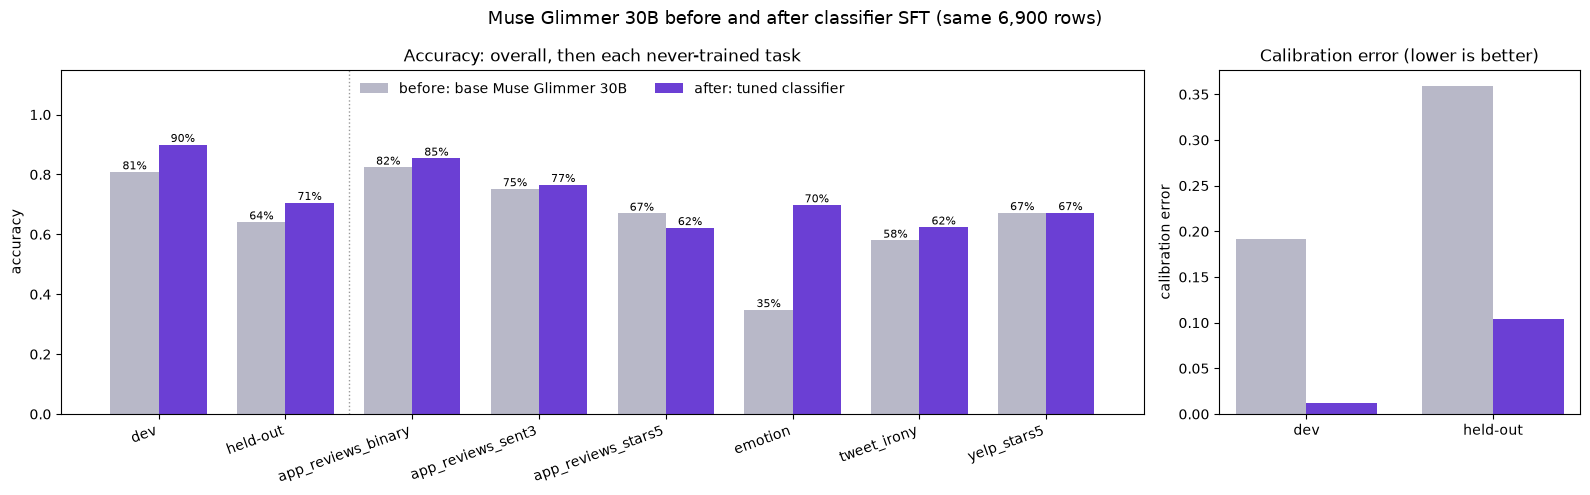

dev: 80.8% -> 90.0% (+9.2 points)
held-out: 64.1% -> 70.6% (+6.5 points)


In [21]:
held_tasks = sorted({r["task"] for r in rows["heldout"]})
slices = [("dev", dict(split="dev")), ("held-out", dict(split="heldout"))] + [(t, dict(task=t)) for t in held_tasks]
pick = lambda label, kw: [r for r in RESULTS[label] if all(r[k] == v for k, v in kw.items())]
stats = {label: [H.summarize(pick(label, kw)) for _, kw in slices] for label in RESULTS}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [3, 1]})
x = np.arange(len(slices))
for i, (label, color) in enumerate((("before", "#b8b8c8"), ("after", "#6b3fd4"))):
    acc = [s["accuracy"] for s in stats[label]]
    bars = ax1.bar(x + (i - 0.5) * 0.38, acc, 0.38, color=color, label=f"{label}: {'base Muse Glimmer 30B' if label == 'before' else 'tuned classifier'}")
    ax1.bar_label(bars, [f"{a:.0%}" for a in acc], fontsize=8)
    err = [stats[label][j]["calibration_error"] for j in (0, 1)]
    ax2.bar(np.arange(2) + (i - 0.5) * 0.38, err, 0.38, color=color, label=label)
ax1.set_xticks(x, [name for name, _ in slices], rotation=20, ha="right")
ax1.axvline(1.5, color="#999", lw=1, ls=":")
ax1.set(ylim=(0, 1.15), ylabel="accuracy", title="Accuracy: overall, then each never-trained task")
ax1.legend(loc="upper center", ncol=2, frameon=False)
ax2.set_xticks(np.arange(2), ["dev", "held-out"])
ax2.set(ylabel="calibration error", title="Calibration error (lower is better)")
fig.suptitle("Muse Glimmer 30B before and after classifier SFT (same 6,900 rows)", fontsize=13)
plt.tight_layout(); plt.savefig(WORK / "before_after.png", dpi=150); plt.show()
for j, (name, _) in enumerate(slices[:2]):
    b, a = stats["before"][j]["accuracy"], stats["after"][j]["accuracy"]
    print(f"{name}: {b:.1%} -> {a:.1%} ({(a - b) * 100:+.1f} points)")

In [12]:
by = lambda **kw: [r for r in results if all(r[k] == v for k, v in kw.items())]
table = pd.DataFrame([{"slice": s, **H.summarize(by(split=s))} for s in ("dev", "heldout")]
                     + [{"slice": t, **H.summarize(by(task=t))} for t in held_tasks])
display(table.round(3))

,slice,n,accuracy,calibration_error,format_miss
0,dev,3900,0.900,0.012,0.0
1,heldout,3000,0.706,0.104,0.0
2,app_reviews_binary,500,0.854,0.090,0.0
3,app_reviews_sent3,500,0.766,0.135,0.0
4,app_reviews_stars5,500,0.622,0.097,0.0
5,emotion,500,0.698,0.069,0.0
6,tweet_irony,500,0.624,0.216,0.0
7,yelp_stars5,500,0.672,0.060,0.0


### Calibration

Points on the diagonal mean "80% confident" is right 80% of the time; below it means overconfident. One
temperature, fit on dev rows only, rescales the probabilities; if held-out calibration error also drops, the
fix carries over to tasks it was not fit on. Accuracy does not change.

In [ ]:
scored = {s: [r for r in by(split=s) if not r["format_miss"]] for s in ("dev", "heldout")}
T = H.fit_temperature(scored["dev"])
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1)
for s, rs in scored.items():
    H.reliability(ax, rs, f"{s}: error {H.ece(rs):.3f} raw -> {H.ece(rs, T):.3f} after T={T:.2f}", t=T)
ax.set(xlabel="stated confidence", ylabel="fraction correct", xlim=(0, 1), ylim=(0, 1))
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(WORK / "reliability.png", dpi=150); plt.show()
(WORK / "calibration.json").write_text(json.dumps({"model": TUNED_MODEL, "temperature": T}))
print(f"apply at inference: probabilities = softmax(log p / {T:.3f})")